In [1]:
import json
import numpy as np
from PIL import Image
import os

## 可视化训练集

In [2]:
train_data_path = 'data_backup/formalgeo7k/formalgeo7k_v2/custom_json/qa_resoning/v2/formalgeov2_aug_train_data.json'
image_path = 'data_backup/formalgeo7k/formalgeo7k_v2/'
with open(train_data_path, 'r') as f:
    train_data = json.load(f)

diagrams/6018.png


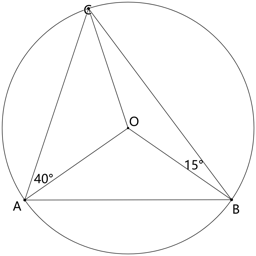

<image>
Using the provided geometric image and question, first predict the construction_cdl and image_cdl. Then, give a detailed step-by-step solution.
The question is:
In the given diagram, given that ∠CAO equals 40 degrees and ∠OBC equals 15 degrees, with O being the center of circle O, determine the measurement of ∠BOA.
A: 55°
B: 120°
C: 150°
D: 110°
The construction_cdl is:
Shape(OCA,AC),Shape(CA,AO,OC),Shape(OA,AB,BO),Shape(OAB,BA),Shape(OB,BC,CO),Shape(OBC,CB),Cocircular(O,ABC)
The image_cdl is:
Equal(MeasureOfAngle(CAO),40),Equal(MeasureOfAngle(OBC),15)
Solution is:
Step 1: Identify that ∠OBC = 15° and ∠CAO = 40°.
Step 2: Recognize that O is the center of circle O, so OC and OB are both radii.
Step 3: Conclude that △OBC is isosceles because OC = OB.
Step 4: Use the property of isosceles triangles to find that ∠BCO = ∠OBC = 15°.
Step 5: Recognize that ∠BCA = ∠BCO + ∠OCA.
Step 6: Identify that OA is also a radius of the circle, so △OCA is isosceles.
Step 7: Use the property of iso

In [34]:
idx = 504
data = train_data[idx]
q = data['conversations'][0]['value']
a = data['conversations'][1]['value']
image = Image.open(os.path.join(image_path, data['image']))
print(data['image'])
display(image.resize((256, 256)))
print(q)
print(a)


## 可视化测试集

In [35]:
gt_path = 'data_backup/formalgeo7k/formalgeo7k_v2/problems_withAns'
pred_path = 'outputs/report/bunny-yi1.5-9B-Chat-FormalGeoCoT-VisionPretrained-sft1e-v21'
image_path = 'data_backup/formalgeo7k/formalgeo7k_v2/diagrams'

prob id is: 1682


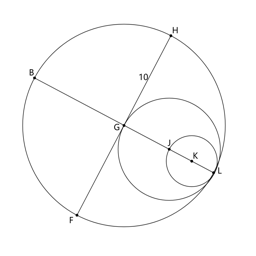

Using the provided geometric image and the possibly erroneous construction_cdl and image_cdl, first calibrate the construction_cdl and image_cdl, then give a detailed step-by-step solution to the question.
The initial construction_cdl is:
Shape(GHB,BG,GH),Shape(GBF,FG,GB),Shape(GF,GFl,JGL),Shape(JG,JGL,KJL),Shape(KJ,KJL,LK),Shape(KL,KLJ,JK),Shape(JLG,GJ,KLJ),Shape(GLH,HG,JLG),Collinear(BGJKL),Collinear(HGF),Cocircular(G,HBFL),Cocircular(J,GL),Cocircular(K,DJICL)
The initial image_cdl is:
Equal(LengthOfLine(GH),10)
The question is:
As shown in the diagram, GH=10, G is the center of circle G, the center of circle J is J, the center of ⊙K is K. Find the length of line JK.



由题意得，GH=10（1），G是圆G的圆心（2），J是圆J的圆心（3），K是圆K的圆心（4）；
由常识可得，GL=JG+JL（5）；
已知条件（2），由常识可得，GH=Radius(⊙G)（6）；
已知条件（6）（1），计算可得，Radius(⊙G)=10（7）；
已知条件（2），由常识可得，GL=Radius(⊙G)（8）；
已知条件（7）（8），计算可得，GL=10（9）；
已知条件（3），由常识可得，JG=Radius(⊙J)（10）；
已知条件（3），由常识可得，JL=Radius(⊙J)（11）；
已知条件（5）（9）（10）（11），计算可得，JL=5（12）；
已知条件（4），由常识可得，JK=Radius(⊙K)（

In [59]:
with open('data_backup/formalgeo7k/formalgeo7k_v2/test.json', 'r') as f:
    test_prob_ids = json.load(f).keys()
test_prob_ids = list(test_prob_ids)

idx = 1000
prob_id = test_prob_ids[idx]
print(f'prob id is: {prob_id}')

image = Image.open(os.path.join(image_path, f'{prob_id}.png'))

# 读取GT
with open(os.path.join(gt_path, f'{prob_id}.json'), 'r') as f:
    gt_info = json.load(f)
gt_solution = gt_info['formalSSS_Solution']
gt_origin_qa = gt_info['origin_qa']


# 读取预测信息
pred_dict = {}
with open(os.path.join(pred_path, 'formalgeo_test_qs_meta_Q+PredCDL2CalibrateCDLandAns_merged.jsonl'), 'r') as f:
    for line in f:
        cur_info = json.loads(line)
        pred_dict[cur_info['question_id']] = cur_info

pred_info = pred_dict[prob_id]
prompt = pred_info['prompt']
pred_solution = pred_info['text']


display(image.resize((256, 256)))
print(prompt + '\n\n\n')
print(gt_solution + '\n\n\n' )
print(pred_solution + '\n\n\n')
